# Tennessee Eastman Process — Datensynthese

Erzeugt Kampagnen-, Produktions- und Fehlerfalldaten (IDV 29, Kalibrierdrift auf XMEAS(18)) des angepassten Tennessee Eastman-Prozesses und speichert sie als `data_campaign`/`data_production`/`data_error` (plus `data_prerun`) im `data_dir`; *tep_model*, *tep_detection* und *tep_adaptation* laden von dort weiter.

Basierend auf Package `pytep`: zugehörige Doku https://github.com/ccreinartz11/pytep. Python ist lediglich Schnittstelle, eigentliche Simulation in Matlab

In [ ]:
import os
from pathlib import Path

work_dir = os.getcwd()
DEFAULT_BASE_DIR = os.path.normpath(os.path.join(work_dir, "..", ".."))

base_dir = Path(os.environ.get("BASE_DIR", DEFAULT_BASE_DIR)).resolve()
data_dir = base_dir / "data" / "tep"
plot_dir = base_dir / "plots"
results_dir = base_dir / "results"

for directory in (plot_dir, data_dir, results_dir):
    os.makedirs(directory, exist_ok=True)

FORCE_RECOMPUTE = False
FORCE_PRERUN = False
FORCE_IDV_RECOMPUTE = False
IS_FINAL = True

In [14]:
SEED = 42
RAMP_DURATION = 48.0
SOAK_TIME = 96.0            # >= RAMP_DURATION
BOUNDARY_TOL = 0.1
ERROR_VARIANT_ID = 29
ERROR_VARIANT_AMP = 0.3

T_TOTAL = 19_728.0          # alle fahrbaren Punkte a RAMP_DURATION + SOAK_TIME

DRIFT_PERIOD, DRIFT_GAMMA, DRIFT_SEED = 1752.0, 0.2, 42   # wie in temexd_mod.c

MAX_PRODUCTION_PASSES = 2

N_PER_MODE = 49
MAXIMIN_TRIES = 200

## Rebuild second group of Reinartz et al

In [15]:
import pandas as pd

setpoint_data = {
    "Production":            [22.89, 22.73, 18.04, 36.04, 23.55, 20.2],
    "Stripper level":        [50,    50,    50,    50,    50,    50],
    "Separator level":       [50,    50,    50,    50,    50,    50],
    "Reactor level":         [65,    65,    65,    65,    65,    65],
    "Reactor pressure":      [2800,  2800,  2800,  2800,  2800,  2800],
    "Mol % G":               [53.8,  11.66, 90.09, 53.35, 11.65, 90.07],
    "yA":                    [63.137,64.196,62.11, 61.94, 64.03, 61.468],
    "yAC":                   [51,    54.24, 47.43, 58.76, 54.32, 48.79],
    "Reactor temperature":   [122.9, 124.2, 121.9, 128.2, 124.6, 123],
    "Recycle valve pos.":    [1,     1,     77.62, 1,     1,     71.166],
    "Steam valve pos.":      [1,     1,     1,     1,     1,     1],
    "Agitator setting":      [100,   100,   100,   100,   100,   100],
}

original_setpoints = pd.DataFrame(setpoint_data)
original_setpoints


,Production,Stripper level,Separator level,Reactor level,Reactor pressure,Mol % G,yA,yAC,Reactor temperature,Recycle valve pos.,Steam valve pos.,Agitator setting
0,22.89,50,50,65,2800,53.80,63.137,51.00,122.9,1.000,1,100
1,22.73,50,50,65,2800,11.66,64.196,54.24,124.2,1.000,1,100
2,18.04,50,50,65,2800,90.09,62.110,47.43,121.9,77.620,1,100
3,36.04,50,50,65,2800,53.35,61.940,58.76,128.2,1.000,1,100
4,23.55,50,50,65,2800,11.65,64.030,54.32,124.6,1.000,1,100
5,20.20,50,50,65,2800,90.07,61.468,48.79,123.0,71.166,1,100


Initialize Simulator 

In [16]:
import pytep.siminterface as siminterface

si = siminterface.SimInterface().setup()

Use index names from pyTEP repo

In [17]:
sp_cols = list(si._setpoint_data.columns)
original_setpoints.columns = sp_cols

Show initial setpoint: should be `Base case` -> `Mode 1` 

In [18]:
[si._matlab_bridge._eng.get_sp_generic(label) for label in sp_cols]

[22.89, 50.0, 50.0, 65.0, 2800.0, 53.8, 63.137, 51.0, 122.9, 1.0, 1.0, 100.0]

Betriebsfenster nach Reinartz et al.: ±15 % um die Modusnennwerte, Inkrement 5 % → sieben Stufen.

In [19]:
import numpy as np

MAGNITUDES = np.linspace(-0.15, 0.15, 7)

### Versuchsplan

Je Betriebsmodus ein Maximin-Latin-Hypercube in dessen ±15-%-Box, dazu der unveränderte Modusnennwert. Die Reihenfolge ist modusverschränkt: erst die sechs Nennwerte, dann reihum Modus 0..5.

Der Prerun ist zugleich der Kampagnenlauf — jeder Punkt isoliert vom selben Ausgangszustand. Produktion und Fehlerfall fahren denselben Pool in randomisierter Reihenfolge.


In [20]:
from scipy.stats import qmc
from scipy.spatial.distance import pdist

lhs_rng = np.random.default_rng(SEED)
MAGNITUDE_LO, MAGNITUDE_HI = MAGNITUDES[0], MAGNITUDES[-1]
CAPPED_NOMINALS = (1.0, 100.0)


def maximin_lhs(n_points, n_dims, tries=MAXIMIN_TRIES):
    draws = [qmc.LatinHypercube(d=n_dims, seed=lhs_rng).random(n=n_points)
             for _ in range(tries)]
    return max(draws, key=lambda unit: pdist(unit).min())


def mode_design(nominal, n_points=N_PER_MODE):
    unit = maximin_lhs(n_points, len(nominal))
    magnitudes = np.vstack([MAGNITUDE_LO + unit * (MAGNITUDE_HI - MAGNITUDE_LO),
                            np.zeros(len(nominal))])
    values = nominal.to_numpy(dtype=float)
    scaled = values * (1.0 + magnitudes)
    at_cap = np.isin(values, CAPPED_NOMINALS) & (scaled > values)
    return np.where(at_cap, values, scaled)


designs = np.stack([mode_design(original_setpoints.loc[mode])
                    for mode in original_setpoints.index])
n_modes, points_per_mode, _ = designs.shape

nominals_first = [(mode, points_per_mode - 1) for mode in range(n_modes)]
interleaved = [(mode, point) for point in range(points_per_mode - 1)
               for mode in range(n_modes)]
order = nominals_first + interleaved

setpoints = pd.DataFrame([designs[mode, point] for mode, point in order],
                         columns=original_setpoints.columns)
setpoint_modes = pd.Series([mode for mode, _ in order], name="mode")
n_runs = len(setpoints)

magnitude_grid = (1.0 + MAGNITUDES)[:, None, None] * original_setpoints.to_numpy()
integer_columns = original_setpoints.columns[
    np.all(np.isclose(magnitude_grid, np.round(magnitude_grid)), axis=(0, 1))]
for col in integer_columns:
    setpoints[col] = np.round(setpoints[col]).astype(int)

print(f"{n_modes} Modi x {points_per_mode} Punkte = {n_runs} Kandidaten "
      f"(davon {n_modes} Nennwerte, zuerst)")

6 Modi x 50 Punkte = 300 Kandidaten (davon 6 Nennwerte, zuerst)


## Simulation

In [21]:
import run_registry as rr

base_run_cfg = {
    "seed": SEED,
    "n": len(setpoints),
    "ramp_h": RAMP_DURATION,
    "soak_h": SOAK_TIME,
    "design": "mode_local_lhs",
    "n_per_mode": N_PER_MODE,
}
run_cfg = {**base_run_cfg, "t_run": T_TOTAL,
           "passes": MAX_PRODUCTION_PASSES}

data_store = rr.tep_data_store(data_dir)
plot_store = rr.tep_plot_store(plot_dir)
base_cfg = rr.RunConfig(base_run_cfg)
cfg = base_cfg.compose(run={"t_run": T_TOTAL,
                            "passes": MAX_PRODUCTION_PASSES})
run_id = cfg.id
print(f"base_id = {base_cfg.id}  (Prerun/Kampagne)")
print(f"run_id  = {run_id}  (Produktion/Fehlerfall)")

base_id = 30098669  (Prerun/Kampagne)
run_id  = 6fe76fde  (Produktion/Fehlerfall)


In [22]:
# Shutdown-Schranken aus temexd_mod.c (Z. 3279 ff.), umgerechnet auf die
# Einheiten von si._process_data: Volumina dort in ft3, Fuellstaende als
# xmeas[7]/[11]/[14] in %.
FT3_PER_M3 = 35.3145


def level_pct(volume_m3, offset, span):
    return (volume_m3 * FT3_PER_M3 - offset) / span * 100.0


SHUTDOWN_LIMITS = {                                                  # (low, high)
    "Reactor Pressure":    (None, 3000.0),                                # isd 1
    "Reactor Level":       (level_pct(2.0, 84.6, 666.7),
                            level_pct(24.0, 84.6, 666.7)),               # isd 3/2
    "Reactor Temperature": (None, 175.0),                                 # isd 4
    "Product Sep Level":   (level_pct(1.0, 27.5, 290.0),
                            level_pct(12.0, 27.5, 290.0)),               # isd 6/5
    "Stripper Level":      (level_pct(1.0, 78.25, 156.5),
                            level_pct(8.0, 78.25, 156.5)),               # isd 8/7
}

SETPOINTS_NOM = {"Reactor Pressure": 2800.0, "Reactor Temperature": 122.9,
                 "Reactor Level": 65.0, "Product Sep Level": 50.0,
                 "Stripper Level": 50.0}

SP_COL = {"Reactor Pressure": "ReactorPressSP", "Reactor Level": "ReactorLevelSP",
          "Reactor Temperature": "ReactorTempSP", "Product Sep Level": "SepLevelSP",
          "Stripper Level": "StripLevelSP"}

In [23]:
def check_limits(si, limits: dict, *, data=None):
    row = (si._process_data if data is None else data).iloc[-1]
    for key, (lo, hi) in limits.items():
        val = float(row[key])
        if hi is not None and val > hi:
            yield f"    {key} exceeded upper limit {hi:.2f}. Current value: {val:.2f}"
        if lo is not None and val < lo:
            yield f"    {key} fell below lower limit {lo:.2f}. Current value: {val:.2f}"

Pre-run function: find stationary operation points

In [24]:
import time
import datetime


def min_reserve(si, setpoint_values, *, data=None):
    """Kleinste Reserve zur Shutdown-Schranke: 1.0 auf dem Sollwert, 0.0 an der Schranke."""
    row = (si._process_data if data is None else data).iloc[-1]
    worst, binding = np.inf, None
    for key, (lo, hi) in SHUTDOWN_LIMITS.items():
        col = SP_COL.get(key)
        setpoint = (float(setpoint_values[col]) if col in setpoint_values.index
                    else SETPOINTS_NOM[key])
        value = float(row[key])
        for bound, sign in ((hi, 1.0), (lo, -1.0)):
            if bound is None:
                continue
            span = sign * (bound - setpoint)
            reserve = -np.inf if span <= 0 else 1.0 - sign * (value - setpoint) / span
            if reserve < worst:
                worst, binding = reserve, key
    return float(worst), binding


def find_successful_operation_points(si: siminterface.SimInterface,
                                     setpoints: pd.DataFrame,
                                     *, store=None, cfg=None,
                                     case="data_prerun", data_case="data_campaign",
                                     meta=None, records=None, frames=None,
                                     modes=None, save_every=1):
    """Prerun ueber alle Kandidaten, zugleich Kampagnenlauf.

    Fortsetzbar: Protokoll und Kampagnendaten werden alle `save_every` Kandidaten
    gemeinsam fortgeschrieben.  Rueckgabe: (fahrbare Indizes, records, campaign_data).
    """
    records = dict(records or {})
    frames = list(frames or [])
    n_total = len(setpoints)
    t0, n_new, n_since_save = time.time(), 0, 0

    def save_progress():
        if store is None or cfg is None:
            return
        store.save({"meta": meta or {}, "records": records}, case, cfg)
        if frames:
            store.save(pd.concat(frames, ignore_index=True), data_case, cfg)

    print(f"Prerun/Kampagne: {len(records)} von {n_total} vorhanden, "
          f"{n_total - len(records)} zu rechnen  |  Start "
          f"{datetime.datetime.now():%d.%m. %H:%M}", flush=True)

    for idx, setpoint_values in setpoints.iterrows():
        if idx in records:
            continue
        for label, value in setpoint_values.items():
            si.ramp_setpoint(setpoint_label=label, target_val=float(value), duration=RAMP_DURATION)
        si.simulate(SOAK_TIME)

        status = si._matlab_bridge.get_sim_status()
        t_end = float(si._process_data["time"].max())
        violations = list(check_limits(si, SHUTDOWN_LIMITS))
        reserve, binding = min_reserve(si, setpoint_values)
        ok = bool(status == "paused")
        records[idx] = {"ok": ok, "status": str(status),
                        "violations": violations,
                        "reserve": reserve, "binding": binding, "t_end": t_end}
        if ok:
            frames.append(_collect_step(si, idx, status))
        si.reset()

        n_new += 1
        n_since_save += 1
        if n_since_save >= save_every:
            save_progress()
            n_since_save = 0

        n_done = len(records)
        n_ok = sum(r["ok"] for r in records.values())
        left = n_total - n_done
        per = (time.time() - t0) / n_new
        eta = datetime.datetime.now() + datetime.timedelta(seconds=per * left)
        mode = "-" if modes is None else modes.get(idx, "-")
        print(f"[{n_done:3d}/{n_total}] Md{mode} #{idx:<3d} "
              f"{'ok  ' if ok else 'STOP'} Res {reserve:6.2f} "
              f"({binding if binding else '-'}) | "
              f"Ausbeute {n_ok:3d}/{n_done:3d} = {n_ok / n_done:4.0%} | "
              f"{per / 60:4.1f} min/Pkt, noch {left:3d} = {per * left / 3600:4.1f} h, "
              f"fertig ~{eta:%H:%M}", flush=True)
        if not ok:
            print(f"        t_end {t_end:.1f} h, status {status}", flush=True)
            for violation in violations:
                print(violation, flush=True)

    if n_since_save:
        save_progress()
    if n_new:
        print(f"\nFertig: {sum(r['ok'] for r in records.values())} fahrbar von "
              f"{len(records)}  |  {(time.time() - t0) / 3600:.1f} h fuer "
              f"{n_new} Kandidaten", flush=True)

    data = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    return [i for i, r in records.items() if r["ok"]], records, data

Simulation function

In [25]:
from typing import Tuple


def _reset_env(si: siminterface.SimInterface, idv: Tuple[int, float]):
    si.reset()
    if idv is not None:
        si.set_idv(idv_idx=idv[0], value=idv[1])


def _ramp_all(si: siminterface.SimInterface, setpoint_values: pd.DataFrame, duration: float):
    for label, value in setpoint_values.items():
        si.ramp_setpoint(setpoint_label=label, target_val=float(value), duration=duration)


def _collect_step(si: siminterface.SimInterface, idx: int, status: str):
    df = pd.concat(
        [si._process_data, si._manipulated_variables,
         si._setpoint_data, si._cost_data, si._idv_data],
        axis=1,
    )
    df["status"] = status
    df["mode"] = idx
    return df


def _ended_off_grid(ts: float, period: float):
    r = ts % period
    return not (r < BOUNDARY_TOL or r > period - BOUNDARY_TOL)


def run_simulation(
    si: siminterface.SimInterface,
    setpoints: pd.DataFrame,
    ramp_duration: float,
    soak_time: float,
    idv: Tuple[int, float] = None,
    reset_modes: list = None,
    runtime: int = 4000,
):
    reset_modes = reset_modes or []
    mode_list = setpoints.index.to_list()
    period = ramp_duration + soak_time

    _reset_env(si, idv)

    all_data = []
    t_start = time.time()
    last_ts = -1.0
    do_reset = False

    for num, (idx, setpoint_values) in enumerate(setpoints.iterrows()):
        next_mode = mode_list[num + 1] if num + 1 < len(mode_list) else None
        if do_reset and reset_modes and idx not in reset_modes:
            print("Skipping mode ", idx, "to reset mode ", next_mode)
            continue

        _ramp_all(si, setpoint_values, ramp_duration)
        si.simulate(soak_time)

        status = si._matlab_bridge.get_sim_status()
        interim_ts = si._process_data["time"].iloc[-1]
        end_batch = (status == "stopped"
                     or interim_ts + period >= runtime
                     or next_mode in reset_modes)

        if not end_batch:
            _ramp_all(si, original_setpoints.iloc[0], ramp_duration)
            si.simulate(ramp_duration)
            status = si._matlab_bridge.get_sim_status()

        for warning in check_limits(si, SHUTDOWN_LIMITS):
            print("Warning for mode ", idx, ":\n", warning)

        df = _collect_step(si, idx, status)
        all_data.append(df.loc[df["time"] > last_ts].copy())
        last_ts = df["time"].iloc[-1]
        elapsed = time.time() - t_start
        per_point = elapsed / (num + 1)
        eta = datetime.datetime.now() + datetime.timedelta(
            seconds=per_point * (len(mode_list) - num - 1))
        print(f"[{num + 1:3d}/{len(mode_list)}] #{idx:<3d} {status:8s} "
              f"t={last_ts:8.1f} h ({last_ts / runtime:4.0%}) | "
              f"{per_point / 60:4.1f} min/Pkt, fertig ~{eta:%H:%M}", flush=True)

        do_reset = end_batch or _ended_off_grid(last_ts, period)
        if do_reset:
            if status == "stopped":
                print("Simulation stopped prematurely at mode ", idx)
            elif last_ts + period >= runtime:
                print(f"Simulation stopped on purpose before {runtime}h.")
            else:
                print("Simulation stopped on purpose after mode ", idx)
            _reset_env(si, idv)
            last_ts = -1.0

    return pd.concat(all_data, ignore_index=True)

Save reset 

In [26]:
def add_reset(data: pd.DataFrame):
    data["reset"] = False
    data.loc[data["time"].diff() < 0, "reset"] = True
    return data


def hold_interval(block):
    """Fenster [t0 + RAMP_DURATION, t0 + SOAK_TIME] eines Modusblocks."""
    t0 = float(block["time"].iloc[0])
    held = block[(block["time"] >= t0 + RAMP_DURATION)
                 & (block["time"] <= t0 + SOAK_TIME)]
    return held if not held.empty else block

## Load/save prerun data

Prerun for independent testing of all operating points of doe

In [27]:
_prerun_records, _prerun_frames = {}, []
if data_store.exists("data_prerun", base_cfg) and not FORCE_PRERUN:
    _prerun_records = data_store.load("data_prerun", base_cfg, rename=True).get("records", {})
    if data_store.exists("data_campaign", base_cfg):
        stored_campaign = data_store.load("data_campaign", base_cfg, rename=True)
        stored_modes = set(stored_campaign["mode"].unique())
        _prerun_frames = [stored_campaign]
        _prerun_records = {i: r for i, r in _prerun_records.items()
                           if r["status"] != "paused" or i in stored_modes}
    else:
        _prerun_records = {i: r for i, r in _prerun_records.items()
                           if r["status"] != "paused"}
    print(f"Prerun-Stand geladen: {len(_prerun_records)} von {len(setpoints)} Kandidaten")

_prerun_complete = (not FORCE_PRERUN) and len(_prerun_records) >= len(setpoints)
_prerun_complete

Prerun-Stand geladen: 300 von 300 Kandidaten


True

In [28]:
if _prerun_complete:
    successful_modes = [i for i, r in _prerun_records.items() if r["ok"]]
    campaign_data = data_store.load("data_campaign", base_cfg, rename=True)
    print(f"Prerun vollstaendig: {len(successful_modes)} fahrbar von "
          f"{len(_prerun_records)}, Kampagnendaten {len(campaign_data)} Zeilen")

Prerun vollstaendig: 137 fahrbar von 300, Kampagnendaten 263177 Zeilen


In [29]:
PRERUN_SAVE_EVERY = 20

if not _prerun_complete:
    successful_modes, _prerun_records, campaign_data = find_successful_operation_points(
        si, setpoints, store=data_store, cfg=base_cfg, meta=base_run_cfg,
        records=_prerun_records, frames=_prerun_frames, modes=setpoint_modes,
        save_every=PRERUN_SAVE_EVERY)
    campaign_data["original_index"] = campaign_data.index
    campaign_data = add_reset(campaign_data)
    campaign_data.attrs = base_run_cfg
    data_store.save(campaign_data, "data_campaign", base_cfg)

In [30]:
ok_flags = pd.Series({i: r["ok"] for i, r in _prerun_records.items()}, dtype=bool)
yield_by_mode = (pd.DataFrame({"ok": ok_flags,
                               "mode": setpoint_modes.reindex(ok_flags.index)})
                 .groupby("mode")["ok"].agg(fahrbar="sum", geprueft="count"))
yield_by_mode["Ausbeute"] = yield_by_mode["fahrbar"] / yield_by_mode["geprueft"]
print(yield_by_mode.to_string(float_format=lambda v: f"{v:.0%}"))
print(f"\ngesamt: {len(successful_modes)} fahrbar von {len(_prerun_records)} "
      f"({len(successful_modes) / max(1, len(_prerun_records)):.0%})")

reserves = pd.Series({i: _prerun_records[i]["reserve"] for i in successful_modes})
production_modes = sorted(successful_modes)
pool_hours = len(production_modes) * (RAMP_DURATION + SOAK_TIME)
print(f"\nReserve fahrbarer Punkte: min {reserves.min():.2f}, "
      f"Median {reserves.median():.2f}, max {reserves.max():.2f}")
print(f"Produktionspool: {len(production_modes)} Punkte, {pool_hours:.0f} h "
      f"= {pool_hours / 8760:.2f} Jahre")
if pool_hours > T_TOTAL:
    print(f"  ACHTUNG: laenger als T_TOTAL = {T_TOTAL:.0f} h -- die letzten "
          f"{int((pool_hours - T_TOTAL) // (RAMP_DURATION + SOAK_TIME)) + 1} Punkte "
          "werden nicht gefahren.")

production_order = list(np.random.default_rng(SEED + 1).permutation(production_modes))

      fahrbar  geprueft  Ausbeute
mode                             
0          35        50       70%
1          21        50       42%
2          23        50       46%
3          23        50       46%
4          16        50       32%
5          19        50       38%

gesamt: 137 fahrbar von 300 (46%)

Reserve fahrbarer Punkte: min 0.09, Median 0.97, max 1.00
Produktionspool: 137 Punkte, 19728 h = 2.25 Jahre


## Produktionslauf (nominal)

Alle fahrbaren Punkte in randomisierter Reihenfolge, ohne Reservefilter. Referenz für `RMSE_frei` und Gegenprobe, dass die Sensordrift den Prozess nicht berührt. Aussortiert wird allein über den zweiten Durchgang.


In [31]:
_prod_loaded_from_cache = data_store.exists("data_production", cfg) and not FORCE_RECOMPUTE
_prod_loaded_from_cache

True

In [32]:
if _prod_loaded_from_cache:
    production_data = data_store.load("data_production", cfg, rename=True)
    print(f"Produktionslauf geladen aus Cache ({len(production_data)} Zeilen)")

Produktionslauf geladen aus Cache (348481 Zeilen)


Lauf


In [33]:
if not _prod_loaded_from_cache:
    production_data = run_simulation(si, setpoints.loc[production_order],
                                     RAMP_DURATION, SOAK_TIME, runtime=T_TOTAL)
    production_data["original_index"] = production_data.index
    production_data = add_reset(production_data)
    production_data.attrs = run_cfg

Zweiter Lauf — Abbrecher aussortieren

Ein vorzeitiger Abbruch bricht den Block und `si.reset()` setzt die Driftuhr zurück. Der zweite Lauf wiederholt ohne die Abbrecher und liefert einen durchgehenden Block. Weil die Sensordrift den Prozess nicht berührt, ist der Fehlerlauf prozessseitig identisch zum nominalen — ein sauberer nominaler Lauf garantiert einen sauberen Fehlerlauf.


In [34]:
if not _prod_loaded_from_cache:
    for attempt in range(1, MAX_PRODUCTION_PASSES + 1):
        last_status = production_data.groupby("mode", sort=False)["status"].last()
        stopped = last_status[last_status == "stopped"].index.tolist()
        if not stopped:
            print(f"Durchgang {attempt}: kein Abbruch.")
            break
        if attempt == MAX_PRODUCTION_PASSES:
            print(f"Durchgang {attempt}: noch {len(stopped)} Abbrecher {stopped}, Budget "
                  "erschoepft -- MAX_PRODUCTION_PASSES erhoehen und wiederholen.")
            break

        print(f"Durchgang {attempt}: {len(stopped)} Abbrecher {stopped} -> Wiederholung "
              f"mit {len(production_order) - len(stopped)} Punkten")
        production_order = [m for m in production_order if m not in stopped]
        production_modes = [m for m in production_modes if m not in stopped]

        production_data = run_simulation(si, setpoints.loc[production_order],
                                         RAMP_DURATION, SOAK_TIME, runtime=T_TOTAL)
        production_data["original_index"] = production_data.index
        production_data = add_reset(production_data)
        production_data.attrs = run_cfg

    data_store.save(production_data, "data_production", cfg)

Zusammenfassung


In [35]:
MIN_POINTS_PER_MODE = 12

last_production_status = production_data.groupby("mode", sort=False)["status"].last()
stopped_in_production = last_production_status[
    last_production_status == "stopped"].index.tolist()
n_resets = int(production_data["reset"].sum())
t_end_production = float(production_data["time"].max())
print(f"Produktionslauf: {production_data['mode'].nunique()} Betriebspunkte, "
      f"{n_resets} Resets, {len(stopped_in_production)} vorzeitige Abbrueche, "
      f"letzte Blockzeit {t_end_production:.0f} h")
if stopped_in_production or n_resets:
    print("  abgebrochen:", stopped_in_production)
    print("  MAX_PRODUCTION_PASSES erhoehen und wiederholen.")
else:
    print("  Ein durchgehender Block, kein Reset.")

points_per_mode_count = (setpoint_modes.reindex(production_data["mode"].unique())
                         .value_counts().sort_index())
print("\nProduktionspunkte je Modus:\n" + points_per_mode_count.to_string())
if points_per_mode_count.min() < MIN_POINTS_PER_MODE:
    print(f"  Modus {points_per_mode_count.idxmin()} hat nur "
          f"{points_per_mode_count.min()} Punkte -- die modusweise "
          "Abstandskurve traegt dort nicht.")

Produktionslauf: 121 Betriebspunkte, 0 Resets, 0 vorzeitige Abbrueche, letzte Blockzeit 17424 h
  Ein durchgehender Block, kein Reset.

Produktionspunkte je Modus:
0    35
1    21
2    16
3    20
4    16
5    13


In [36]:
print(f"Kampagne (Prerun): {campaign_data['mode'].nunique()} Betriebspunkte, "
      f"{len(campaign_data)} Zeilen")

Kampagne (Prerun): 137 Betriebspunkte, 263177 Zeilen


### Verschleppung? Kampagne gegen Produktion

Der Prerun setzt vor jedem Punkt hart auf Mode 1 zurück, der Produktionslauf fährt über eine 48-h-Zwischenrampe dorthin. Ein Rest davon im Halteintervall wäre ein systematischer Versatz zwischen Trainings- und Produktionsdaten.

Maßstab ist die erwartete driftbedingte Verschiebung von rund 20 Kosteneinheiten: der Versatz muss deutlich darunter bleiben.


In [37]:
DRIFT_SHIFT_REF = 20.0
RESIDUE_OK = 0.2
RESIDUE_BORDERLINE = 0.5

numeric_cols = [c for c in production_data.columns
                if production_data[c].dtype.kind == "f"
                and c not in ("time", "original_index") and not c.startswith("IDV")]


def mean_per_mode(df):
    return pd.DataFrame({mode: hold_interval(block)[numeric_cols].mean()
                         for mode, block in df.groupby("mode", sort=False)}).T


campaign_means, production_means = mean_per_mode(campaign_data), mean_per_mode(production_data)
common_modes = campaign_means.index.intersection(production_means.index)
delta = production_means.loc[common_modes] - campaign_means.loc[common_modes]
spread_between_modes = production_means.loc[common_modes].std()
print(f"{len(common_modes)} Betriebspunkte in beiden Datensaetzen\n")

if "cost" in numeric_cols:
    bias = float(delta["cost"].mean())
    scatter = float(delta["cost"].std())
    rms = float(np.sqrt((delta["cost"] ** 2).mean()))
    print("cost, Produktion minus Kampagne je Betriebspunkt:")
    print(f"  konstanter Versatz : {bias:+8.2f}   (vom Modell als Niveau absorbiert)")
    print(f"  Streuung darum     : {scatter:8.2f}   (nicht absorbierbar)")
    print(f"  RMS gesamt         : {rms:8.2f}")
    print(f"  Streuung ueber die Betriebspunkte : {spread_between_modes['cost']:8.2f}")
    print(f"  erwartete Driftverschiebung       : {DRIFT_SHIFT_REF:8.2f}")

    residue_ratio = scatter / DRIFT_SHIFT_REF
    print(f"\n  Streuung / Driftverschiebung = {residue_ratio:.2f}")
    if residue_ratio < RESIDUE_OK:
        print("  -> Zwischenrampe entbehrlich.")
    elif residue_ratio < RESIDUE_BORDERLINE:
        print("  -> Grenzwertig, Zwischenrampe auf 96 h verlaengern.")
    else:
        print("  -> Zwischenrampe wird gebraucht und muss laenger werden.")

relative_shift = (delta.abs().mean()
                  / spread_between_modes.replace(0.0, np.nan)).dropna().sort_values(ascending=False)
print("\nGroesste systematische Verschiebungen, relativ zur Streuung ueber die Punkte:")
print(relative_shift.head(10).to_string(float_format=lambda v: f"{v:.3f}"))


121 Betriebspunkte in beiden Datensaetzen

cost, Produktion minus Kampagne je Betriebspunkt:
  konstanter Versatz :    +0.99   (vom Modell als Niveau absorbiert)
  Streuung darum     :     6.00   (nicht absorbierbar)
  RMS gesamt         :     6.06
  Streuung ueber die Betriebspunkte :   205.98
  erwartete Driftverschiebung       :    20.00

  Streuung / Driftverschiebung = 0.30
  -> Grenzwertig, Zwischenrampe auf 96 h verlaengern.

Groesste systematische Verschiebungen, relativ zur Streuung ueber die Punkte:
Stripper Steam Flow      0.019
Stripper Level           0.016
Product Sep Pressure     0.014
Reactor Pressure         0.014
Product Sep Level        0.011
Purge valve              0.010
Stripper Pressure        0.010
Component F in Product   0.010
Compressor Work          0.009
Purge Rate               0.009


## Drift-Funktionen (C-Referenzimplementierung)

Kompiliert die Drift-C-Dateien zu Shared Libraries und zeigt das Sägezahn-Driftsignal von IDV(29) (Periode `DRIFT_PERIOD`, IDV-Wert = Amplitude) sowie die Dreieck-Alternative ohne Sudden Drifts. In `temexd_mod_drift.c` wird die Variante über die `#include`-Zeile gewählt.


In [38]:
import subprocess
import sys

GCC = r"C:\msys64\ucrt64\bin\gcc.exe"
drift_srcs = [base_dir / "src" / "drift_function_sawtooth.c",
              base_dir / "src" / "drift_function_triangle.c"]

print("Compiler:", GCC)
build_env = os.environ.copy()
build_env["PATH"] = os.path.dirname(GCC) + os.pathsep + build_env.get("PATH", "")

drift_libs = {}
for source in drift_srcs:
    library = source.with_suffix(".dll" if sys.platform == "win32" else ".so")
    if library.exists() and library.stat().st_mtime >= source.stat().st_mtime:
        drift_libs[source.stem] = library
        print(f"Aktuell -> {library.name} (nicht neu uebersetzt)")
        continue
    cmd = [GCC, "-O2", "-shared", "-DDRIFT_BUILD_DLL", "-o", str(library), str(source)]
    result = subprocess.run(cmd, capture_output=True, text=True,
                            cwd=source.parent, env=build_env)
    if result.returncode != 0:
        raise RuntimeError(f"Kompilierung fehlgeschlagen (Returncode {result.returncode}):\n"
                           f"{result.stdout}\n{result.stderr}")
    drift_libs[source.stem] = library
    print(f"Kompiliert -> {library.name}")


Compiler: C:\msys64\ucrt64\bin\gcc.exe
Aktuell -> drift_function_sawtooth.dll (nicht neu uebersetzt)
Aktuell -> drift_function_triangle.dll (nicht neu uebersetzt)


In [39]:
import ctypes


def _bind(lib_path):
    lib = ctypes.CDLL(str(lib_path))
    lib.drift_signal.restype = ctypes.c_double
    lib.drift_signal.argtypes = [ctypes.c_double, ctypes.c_double,
                                 ctypes.c_double, ctypes.c_ulonglong]
    return lib


_saw = _bind(drift_libs["drift_function_sawtooth"])
_tri = _bind(drift_libs["drift_function_triangle"])


def _eval(lib, t, amplitude, period, gamma, seed):
    return amplitude * np.array([lib.drift_signal(float(x), period, gamma, seed)
                                 for x in np.atleast_1d(t)])


def drift_sawtooth(t, amplitude: float = ERROR_VARIANT_AMP,
                   period: float = DRIFT_PERIOD, gamma: float = DRIFT_GAMMA,
                   seed: int = DRIFT_SEED) -> np.ndarray:
    """Saegezahn analog c[k], t in h; Parameter identisch zu den #defines in temexd_mod.c."""
    return _eval(_saw, t, amplitude, period, gamma, seed)


def drift_triangle(t, amplitude: float = ERROR_VARIANT_AMP,
                   period: float = DRIFT_PERIOD) -> np.ndarray:
    """Dreieck ohne Sudden Drifts."""
    return _eval(_tri, t, amplitude, period, 0.0, 0)


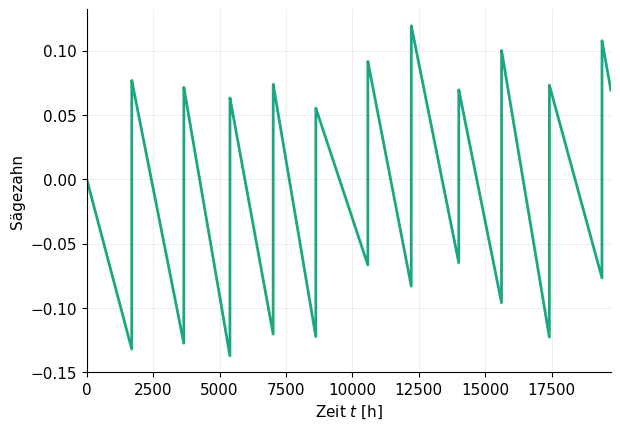

In [40]:
import matplotlib.pyplot as plt
from src.utils import thesis_style as ts

t = np.linspace(0.0, T_TOTAL, 8001)
fig, ax = plt.subplots(figsize=(ts.fig_width(), ts.fig_width(0.7)))
ax.plot(t, drift_sawtooth(t, amplitude=ERROR_VARIANT_AMP), **ts.line("drift_signal"))
ax.set_ylabel("Sägezahn")
ax.grid(True, alpha=0.2)
ax.margins(x=0)
ax.set_xlabel("Zeit $t$ [h]")
plt.tight_layout()
plot_store.save_figure(plt.gcf(), "cd", cfg, final=IS_FINAL)
plt.show()

## Wahl der Drift-Amplitude

IDV(29) wirkt als Kalibrierdrift auf den aufgezeichneten Messwert XMEAS(18) = Stripper Temp; Prozess, Regelung und Zielgröße bleiben unberührt (Belege im Kopf von `temexd_mod.c`). Der relative Kalibrierfehler beträgt `ERROR_VARIANT_AMP · drift_signal(t)`, das Signal selbst überstreicht $[-0{,}5,\ +0{,}5]$.

Zwei Schranken: nach unten muss die Verschiebung des Prädiktionsfehlers über dem Innerpunkt-Rauschen des Modells liegen, nach oben muss der Fehler als schleichende Dekalibrierung plausibel bleiben, also im Bereich weniger Kelvin.


In [41]:
T_STRIPPER_NOM = 60.2      # mittlere Strippertemperatur ueber die Betriebspunkte, °C
SENS_PER_PCT = 4.4         # Kosteneinheiten je Prozent Kalibrierfehler
NOISE_FLOOR = 3.6          # Innerpunkt-Rauschen des Modells
AMPLITUDE_CANDIDATES = (0.1, 0.15, 0.2, 0.3, 0.5)

t_grid = np.linspace(0.0, 4.0 * DRIFT_PERIOD, 40001)
signal = drift_sawtooth(t_grid, amplitude=1.0)
peak, rms = float(np.max(np.abs(signal))), float(np.sqrt(np.mean(signal ** 2)))
print(f"Driftsignal: Spitzenwert |c| = {peak:.2f}, Effektivwert = {rms:.2f}\n")

print(f"{'amp':>6} {'Spitze %':>9} {'Spitze K':>9} {'Eff. %':>8} "
      f"{'Verschieb.':>11} {'ueber Rauschen':>15}")
for amp in AMPLITUDE_CANDIDATES:
    peak_pct, rms_pct = amp * peak * 100, amp * rms * 100
    shift = rms_pct * SENS_PER_PCT
    print(f"{amp:6.2f} {peak_pct:9.1f} {peak_pct / 100 * T_STRIPPER_NOM:9.1f} {rms_pct:8.1f} "
          f"{shift:11.1f} {shift / NOISE_FLOOR:15.1f}")

chosen_peak = ERROR_VARIANT_AMP * peak
print(f"\nGewaehlt: ERROR_VARIANT_AMP = {ERROR_VARIANT_AMP}")
print(f"  Spitzenwert des Kalibrierfehlers {100 * chosen_peak:.1f} % = "
      f"{chosen_peak * T_STRIPPER_NOM:.1f} K")
print(f"  Effektivwert {100 * ERROR_VARIANT_AMP * rms:.1f} % = "
      f"{ERROR_VARIANT_AMP * rms * T_STRIPPER_NOM:.1f} K")
print(f"  erwartete Verschiebung des Praediktionsfehlers "
      f"{ERROR_VARIANT_AMP * rms * 100 * SENS_PER_PCT:.0f} Kosteneinheiten")


Driftsignal: Spitzenwert |c| = 0.46, Effektivwert = 0.23

   amp  Spitze %  Spitze K   Eff. %  Verschieb.  ueber Rauschen
  0.10       4.6       2.8      2.3         9.9             2.8
  0.15       6.9       4.1      3.4        14.9             4.1
  0.20       9.2       5.5      4.5        19.8             5.5
  0.30      13.8       8.3      6.8        29.7             8.3
  0.50      22.9      13.8     11.3        49.5            13.8

Gewaehlt: ERROR_VARIANT_AMP = 0.3
  Spitzenwert des Kalibrierfehlers 13.8 % = 8.3 K
  Effektivwert 6.8 % = 4.1 K
  erwartete Verschiebung des Praediktionsfehlers 30 Kosteneinheiten


## Load/save error data

In [42]:
error_variant = {"idv": ERROR_VARIANT_ID, "amp": ERROR_VARIANT_AMP}
error_cfg = cfg.compose(error=error_variant)
print(f"error_run_id = {error_cfg.id} (Rohdaten {error_cfg.base_id})")

_error_loaded_from_cache = (data_store.exists("data_error", error_cfg)
                            and not FORCE_RECOMPUTE and not FORCE_IDV_RECOMPUTE)
_error_loaded_from_cache


error_run_id = a568acfa (Rohdaten 30098669)


True

In [43]:
if _error_loaded_from_cache:
    error_data = data_store.load("data_error", error_cfg, rename=True)

Simulator neu aufsetzen, damit der Fehlerfall aus definiertem Zustand startet

In [44]:
if not _error_loaded_from_cache:
    si._matlab_bridge.stop_engine()
    si = siminterface.SimInterface().setup()

In [45]:
if not _error_loaded_from_cache:
    error_run_modes = production_data["mode"].unique().tolist()
    reset_modes = production_data.loc[production_data["reset"] == True, "mode"].to_list()
    error_data = run_simulation(si, setpoints.loc[error_run_modes], RAMP_DURATION, SOAK_TIME,
                                idv=(ERROR_VARIANT_ID, ERROR_VARIANT_AMP),
                                reset_modes=reset_modes, runtime=T_TOTAL)
    error_data["original_index"] = error_data.index
    error_data = add_reset(error_data)
    error_data.attrs = run_cfg

    data_store.save(error_data, "data_error", error_cfg)


### Gegenprobe: wirkt IDV(29) nur auf XMEAS(18)?

Beide Läufe liegen gepaart vor. Zusätzlich wird `driftf` aus dem Verhältnis der Strippertemperatur rekonstruiert und gegen die C-Referenz gestellt — weichen beide ab, laufen DLL und mex-Übersetzung auseinander.


In [46]:
PROCESS_EQ_TOL = 1e-9
DRIFTF_SAMPLE_STEP = 20
PERIOD_MAX_SAMPLES = 20000
PERIOD_CANDIDATES = (800.0, 1752.0, DRIFT_PERIOD)

numeric_cols = [c for c in production_data.columns
                if production_data[c].dtype.kind == "f"
                and c not in ("time", "original_index") and not c.startswith("IDV")]
nominal = production_data.set_index(["mode", "time"])[numeric_cols]
faulty = error_data.set_index(["mode", "time"])[numeric_cols]
common_index = nominal.index.intersection(faulty.index)

max_deviation = (faulty.loc[common_index]
                 - nominal.loc[common_index]).abs().max().sort_values(ascending=False)
print(f"{len(common_index)} gemeinsame Zeitpunkte von {len(nominal)} bzw. {len(faulty)}")
print("Groesste Abweichungen Fehlerlauf - nominal:")
print(max_deviation.head(6).to_string())
moved_cols = max_deviation[max_deviation > PROCESS_EQ_TOL].index.tolist()
if moved_cols == ["Stripper Temp"]:
    print("\n-> Nur Stripper Temp bewegt sich: Delta_y = 0, also Delta_e = Delta_y_hat exakt.")
else:
    print(f"\n-> ACHTUNG: es bewegen sich {len(moved_cols)} Spalten: {moved_cols[:8]}")

sample_index = common_index[::DRIFTF_SAMPLE_STEP]
driftf_measured = (faulty.loc[sample_index, "Stripper Temp"]
                   / nominal.loc[sample_index, "Stripper Temp"]).to_numpy()
driftf_reference = 1.0 + ERROR_VARIANT_AMP * drift_sawtooth(
    sample_index.get_level_values("time").to_numpy(), amplitude=1.0)
print(f"\ndriftf: max |gemessen - C-Referenz| = "
      f"{np.abs(driftf_measured - driftf_reference).max():.2e}")
print(f"        gemessen  {driftf_measured.min():.4f} .. {driftf_measured.max():.4f}")
print(f"        Referenz  {driftf_reference.min():.4f} .. {driftf_reference.max():.4f}")


all_times = common_index.get_level_values("time").to_numpy()
all_ratios = (faulty.loc[common_index, "Stripper Temp"]
              / nominal.loc[common_index, "Stripper Temp"]).to_numpy()
period_step = max(1, len(all_times) // PERIOD_MAX_SAMPLES)
period_times, period_ratios = all_times[::period_step], all_ratios[::period_step]

print("\nPeriode   max|Abw|   RMS")
best_rms, best_period = np.inf, None
for period in PERIOD_CANDIDATES:
    predicted = 1.0 + ERROR_VARIANT_AMP * drift_sawtooth(period_times, amplitude=1.0,
                                                         period=period)
    max_abs = float(np.abs(period_ratios - predicted).max())
    rms_abs = float(np.sqrt(((period_ratios - predicted) ** 2).mean()))
    print(f"{period:7.0f} h  {max_abs:8.4f}  {rms_abs:8.4f}")
    if rms_abs < best_rms:
        best_rms, best_period = rms_abs, period
print(f"-> beste Uebereinstimmung bei {best_period:.0f} h "
      f"(Notebook rechnet mit DRIFT_PERIOD = {DRIFT_PERIOD:.0f} h)")
if abs(best_period - DRIFT_PERIOD) > 1e-6:
    print("   ACHTUNG: Simulator und Notebook rechnen mit verschiedenen Perioden; "
          "vermutlich ist die MEX-Datei nicht neu uebersetzt.")


348481 gemeinsame Zeitpunkte von 348481 bzw. 348481
Groesste Abweichungen Fehlerlauf - nominal:
Stripper Temp             9.784626
A Feed                    0.000000
Component D in Product    0.000000
Component E in Product    0.000000
Component F in Product    0.000000
Component G in Product    0.000000

-> Nur Stripper Temp bewegt sich: Delta_y = 0, also Delta_e = Delta_y_hat exakt.

driftf: max |gemessen - C-Referenz| = 1.47e-01
        gemessen  0.8625 .. 1.1468
        Referenz  0.8625 .. 1.1193

Periode   max|Abw|   RMS
    800 h    0.1996    0.0807
   1752 h    0.1469    0.0264
   1752 h    0.1469    0.0264
-> beste Uebereinstimmung bei 1752 h (Notebook rechnet mit DRIFT_PERIOD = 1752 h)


### Gemessenes `driftf` als Spalte

Weil die Sensordrift den Prozess nicht berührt (Δy = 0), ist das Verhältnis der aufgezeichneten Strippertemperatur punktweise **exakt** der Kalibrierfaktor: `x_auf = driftf · x_wahr`. Das ist ein gemessenes Signal und unabhängig von Compiler-Build, Blockzeit und Rekonstruktion aus `DRIFT_PERIOD` — die C-Referenz weicht nachweislich ab (RMS 0,018, also 38 % des Signaleffektivwerts). Der nominale Lauf hat implizit `driftf = 1`.


In [47]:
DRIFT_SEGMENT_JUMP = 0.05
CREF_SAMPLE_STEP = 50

key = ["mode", "time"]
nominal_stripper_temp = production_data.set_index(key)["Stripper Temp"]
error_index = pd.MultiIndex.from_frame(error_data[key])
driftf = (error_data["Stripper Temp"].to_numpy()
          / nominal_stripper_temp.reindex(error_index).to_numpy())

n_unmatched = int(np.isnan(driftf).sum())
if n_unmatched:
    raise ValueError(f"{n_unmatched} Zeilen ohne Gegenstueck im nominalen Lauf -- die beiden "
                     "Laeufe muessen dieselbe Sequenz und dieselben Blockgrenzen haben.")
error_data["driftf"] = driftf

error_data["drift_segment"] = (error_data["driftf"].diff()
                               > DRIFT_SEGMENT_JUMP).cumsum().astype(int)

segments = error_data.groupby("drift_segment")["time"].agg(["min", "max", "count"])
print(f"driftf gemessen: {error_data['driftf'].min():.4f} .. "
      f"{error_data['driftf'].max():.4f}   (erwartet 1 +- {ERROR_VARIANT_AMP * 0.5:.2f})")
print(f"c = (driftf - 1) / amp: {(error_data['driftf'].min() - 1) / ERROR_VARIANT_AMP:+.4f} .. "
      f"{(error_data['driftf'].max() - 1) / ERROR_VARIANT_AMP:+.4f}")
print(f"\n{len(segments)} Driftsegmente ueber {error_data['time'].max():.0f} h "
      f"(nominell {error_data['time'].max() / DRIFT_PERIOD:.1f} Perioden a {DRIFT_PERIOD:.0f} h):")
print(segments.to_string(float_format=lambda v: f"{v:.1f}"))

c_reference = 1.0 + ERROR_VARIANT_AMP * drift_sawtooth(
    error_data["time"].to_numpy()[::CREF_SAMPLE_STEP], amplitude=1.0)
c_deviation = np.abs(error_data["driftf"].to_numpy()[::CREF_SAMPLE_STEP] - c_reference)
print(f"\nAbweichung der C-Referenz: max {c_deviation.max():.4f}, RMS "
      f"{np.sqrt((c_deviation ** 2).mean()):.4f}  (nur dokumentiert, nicht verwendet)")

error_data.attrs = run_cfg
data_store.save(error_data, "data_error", error_cfg)
print("\ndata_error neu gespeichert mit den Spalten 'driftf' und 'drift_segment'.")


driftf gemessen: 0.8625 .. 1.1470   (erwartet 1 +- 0.15)
c = (driftf - 1) / amp: -0.4585 .. +0.4899

12 Driftsegmente ueber 17424 h (nominell 9.9 Perioden a 1752 h):
                  min     max  count
drift_segment                       
0                 0.0     0.0      1
1                 0.1  1693.7  33873
2              1693.7  3652.5  39177
3              3652.6  5390.1  34751
4              5390.1  7018.2  32563
5              7018.2  8623.0  32095
6              8623.0 10581.2  39165
7             10581.2 12216.0  32696
8             12216.1 14002.6  35731
9             14002.6 15613.9  32227
10            15614.0 17413.5  35993
11            17413.6 17424.0    209

Abweichung der C-Referenz: max 0.1468, RMS 0.0264  (nur dokumentiert, nicht verwendet)

data_error neu gespeichert mit den Spalten 'driftf' und 'drift_segment'.


### Kritische Amplitude aus dem Fehlerlauf

Wertet den Fehlerlauf aus, ohne zusätzlich zu simulieren. Der Abstieg des Sägezahns ist quasistatisch, das kritische `driftf` eines Betriebspunkts daher näherungsweise amplitudenunabhängig: aus dem Abbruchzeitpunkt eines Modus folgt

$$A_\mathrm{crit} = \texttt{ERROR\_VARIANT\_AMP} \cdot \frac{|c(t_\mathrm{stop})|}{|c_\mathrm{min}(\mathrm{Segment})|}.$$

Driftphase ist die Blockzeit `error_data["time"]`, weil `si.reset()` `drift_tonset` zurücksetzt.


In [48]:
SEGMENT_SCAN_STEP = 0.5


def segment_min(t, step=SEGMENT_SCAN_STEP):
    """Tiefpunkt des normierten Driftsignals im Segment, in dem t liegt."""
    scan = np.arange(t, t + DRIFT_PERIOD * (1.0 + DRIFT_GAMMA), step)
    signal = drift_sawtooth(scan, amplitude=1.0)
    rise = np.flatnonzero(np.diff(signal) > 0.0)
    return float(signal[: rise[0] + 1].min()) if rise.size else float(signal.min())


last_error_rows = error_data.groupby("mode", sort=False).last()
stopped_in_error = last_error_rows[last_error_rows["status"] == "stopped"]

if stopped_in_error.empty:
    amp_critical = None
    print(f"Fehlerlauf mit IDV({ERROR_VARIANT_ID}) = {ERROR_VARIANT_AMP}: "
          f"kein vorzeitiger Abbruch in {len(last_error_rows)} Betriebspunkten.")
else:
    rows = []
    for mode, row in stopped_in_error.iterrows():
        t_stop = float(row["time"])
        c_stop = float(drift_sawtooth(t_stop, amplitude=1.0)[0])
        c_min = segment_min(t_stop)
        rows.append({"mode": mode, "t_stop": t_stop,
                     "driftf_stop": 1.0 + ERROR_VARIANT_AMP * c_stop,
                     "c_stop": c_stop, "c_min_segment": c_min,
                     "A_crit": ERROR_VARIANT_AMP * abs(c_stop) / abs(c_min)})
    amp_crit_table = pd.DataFrame(rows).sort_values("A_crit").reset_index(drop=True)
    amp_critical = float(amp_crit_table["A_crit"].min())
    print(amp_crit_table.to_string(index=False))
    print(f"\nAbbrueche: {len(amp_crit_table)} von {len(last_error_rows)} Betriebspunkten")
    print(f"Bindender Modus {int(amp_crit_table.loc[0, 'mode'])}: "
          f"A_crit = {amp_critical:.3f}  (gerechnet mit {ERROR_VARIANT_AMP})")
    if amp_critical <= ERROR_VARIANT_AMP:
        print(f"-> ERROR_VARIANT_AMP auf <= {amp_critical:.2f} senken "
              f"fuer einen Lauf ohne vorzeitige Abbrueche.")


Fehlerlauf mit IDV(29) = 0.3: kein vorzeitiger Abbruch in 121 Betriebspunkten.


### Kritikalität der Betriebspunkte

Kennzahl ist die Ausnutzung der Stellreserve im *driftfreien* Testlauf, bezogen auf den Sollwert des jeweiligen Modus:

$$u = \frac{\text{Extremwert} - \text{Sollwert}}{\text{Schranke} - \text{Sollwert}},$$

also $u = 0$ auf dem Sollwert und $u = 1$ an der Shutdown-Schranke. Das DOE streut die Sollwerte um ±15 %, beim Reaktordruck 2380 .. 3220 kPag gegen eine Schranke von 3000 kPag.


 mode  utilisation          binding  setpoint  stopped_in_error_run
  112     0.978712   Stripper Level   47.1916                 False
  195     0.959718 Reactor Pressure 2855.0000                 False
  253     0.928167   Stripper Level   45.3037                 False
  256     0.923783 Reactor Pressure 2436.0000                 False
   88     0.912844 Reactor Pressure 2810.0000                 False
  284     0.900460   Stripper Level   46.7242                 False
  286     0.889385 Reactor Pressure 2387.0000                 False
   97     0.832946   Stripper Level   55.9928                 False
  279     0.826524 Reactor Pressure 2478.0000                 False
   55     0.779187   Stripper Level   44.9995                 False
  144     0.763870 Reactor Pressure 2996.0000                 False
  297     0.752428 Reactor Pressure 2596.0000                 False


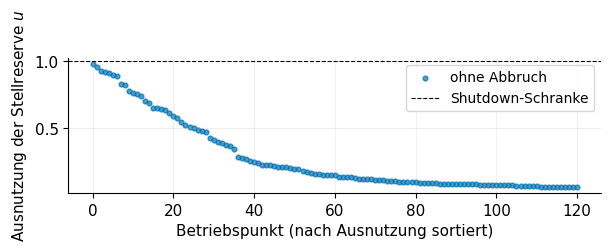

In [49]:
def utilisation(df):
    out = []
    for mode, block in df.groupby("mode", sort=False):
        held = hold_interval(block)
        best = {"utilisation": -np.inf, "binding": None, "setpoint": np.nan}
        for key, (lo, hi) in SHUTDOWN_LIMITS.items():
            col = SP_COL.get(key)
            setpoint = float(held[col].median()) if col in held.columns else SETPOINTS_NOM[key]
            for value, bound, sign in ((held[key].max(), hi, 1.0),
                                       (held[key].min(), lo, -1.0)):
                if bound is None:
                    continue
                span = sign * (bound - setpoint)
                u = np.inf if span <= 0 else sign * (float(value) - setpoint) / span
                if u > best["utilisation"]:
                    best = {"utilisation": u, "binding": key, "setpoint": setpoint}
        out.append({"mode": mode, **best})
    return pd.DataFrame(out).sort_values("utilisation", ascending=False,
                                         ignore_index=True)


criticality = utilisation(production_data)
stopped_error_modes = set(stopped_in_error.index)
criticality["stopped_in_error_run"] = criticality["mode"].isin(stopped_error_modes)

print(criticality.head(12).to_string(index=False))
n_undefined = int(np.isinf(criticality["utilisation"]).sum())
if n_undefined:
    print(f"\n{n_undefined} Modi mit Sollwert jenseits einer Shutdown-Schranke "
          "(Ausnutzung nicht definiert).")
if stopped_error_modes:
    ranks = criticality.index[criticality["stopped_in_error_run"]].tolist()
    print(f"Im Fehlerlauf abgebrochen: Modi {sorted(stopped_error_modes)}, "
          f"Raenge {[r + 1 for r in ranks]} von {len(criticality)}")
    print("Bindende Groessen dort: "
          f"{criticality.loc[criticality['stopped_in_error_run'], 'binding'].tolist()}")

finite = criticality[np.isfinite(criticality["utilisation"])]
fig, ax = plt.subplots(figsize=(ts.fig_width(), ts.fig_width(0.34)))
for mask, label, style in ((~finite["stopped_in_error_run"], "ohne Abbruch",
                            dict(s=12, alpha=0.7)),
                           (finite["stopped_in_error_run"], "im Fehlerlauf abgebrochen",
                            dict(s=34, marker="x", zorder=3))):
    if mask.any():
        ax.scatter(np.flatnonzero(mask), finite.loc[mask, "utilisation"],
                   label=label, **style)
ax.axhline(1.0, ls="--", lw=0.8, color="k", label="Shutdown-Schranke")
ax.set_xlabel("Betriebspunkt (nach Ausnutzung sortiert)")
ax.set_ylabel("Ausnutzung der Stellreserve $u$")
ax.grid(True, alpha=0.2)
ax.legend(loc="upper right")
plt.tight_layout()
plot_store.save_figure(plt.gcf(), "cd_mode_criticality", error_cfg, final=IS_FINAL)
plt.show()


## Lauf abgeschlossen

Zeigt die Kennungen dieses Laufs in einem Fenster mit Kopier-Button (Konsolenausgabe, falls keine GUI verfuegbar ist).

In [50]:
from src.utils.dialogs import show_with_copy_button

show_with_copy_button(
    "Lauf abgeschlossen",
    f"Datensynthese beendet.\n"
    f"Data Run-ID: {run_id}\n"
    f"Fehlerfall (IDV {ERROR_VARIANT_ID}, amp {ERROR_VARIANT_AMP}): {error_cfg.id}",
    copy_value=run_id,
)


--- Lauf abgeschlossen ---
Datensynthese beendet.
Data Run-ID: 6fe76fde
Fehlerfall (IDV 29, amp 0.3): a568acfa

